<a href="https://colab.research.google.com/github/kynodontas-flac/MetodosDigitales_2026_2/blob/main/9_Web%20Scraping/9_Minado_bsky.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minería de datos de redes sociales
#
#
#
#
#### Cada vez es más común el nombrado "cierre de APIs" en las plataformas digitales, por lo que este ejercicio lo haremos con Bluesky (bsky).
#
#
#### Una API (*Application Programming Interface*) es un protocolo utilizado para que dos aplicaciones puedan comunicarse. Una pasarela de pagos, un acceso a una aplicación como Facebook a través de otra app "cliente", un *sign-in* con Google, un pago de contacto con Google Wallet o Apple Pay; todas funcionan encima de una llamada de API.
#
#### bsky, por su parte, es una red social de *microblogging* como X (anteriormente Twitter) que fue creada por una facción de Twitter en 2019 y se volvió la "resistencia" a la compra de este por Elon Musk.
#
#### Esta red social pertenece al AT Protocol, una serie de estándares para una web descentralizada, otra resistencia al "jardín amurallado" (*walled garden*) en que hemos visto que se ha convertido la Internet (véase, Greene. *Landlords of the Internet* en el programa) y que compite, irónicamente, con el "fediverso", un *spin-off* del metaverso con características federativas que se puede activar en Threads.
#
#### Teniendo en cuenta que este protocolo permite el libre intercambio de datos PÚBLICOS a través de json (un estándar para bases de datos), podemos hacer minería o "*scraping*" de la red social sin una llave API, un perfil de desarrollador, permiso o pago alguno.
#
#### Por muchos años, Twitter fue el santo grial de los estudios sociales en digitalidad, pues tenía política de "APIs abiertas", lo que quería decir que con sólo aplicar como desarollador no había una cuota ni monetaria ni de información límite. Sin embargo, si recuerdan, hace unos 3 o 4 años la visualización de Tweets mediante la app se limitó a 200 posts por día. Esto se debía a que dada una pelea con Microsoft por el agresivo scraping de este para entrenamiento de modelos de IA, se estaba negando a costear el funcionamiento de Twitter quienes estaban subiendo los costos de la publicidad, por lo que Twitter decidió cerrar sus APIs. En la actualidad la API de X ha vuelto a funcionar, pero es una API de pago, por lo que hay unas reglas muy estrictas, unos mínimos y máximos de búsqueda y un pago por búsqueda por cantidad de resultados.
#
#### Por ello, aunque bsky no sea tan popular en el país, vamos a aprovechar sus bondades y aprender acerca de minería de datos de redes sociales aplicadas a la investigación sociológica.

In [68]:
# Instalamos AT Protocol y lo importamos como cliente
# El AT Protocol también permite el posteo automatizado de información
# directamente a bsky, pues los bots se permiten siempre y cuando revelen
# que son bots, como solía ser en X
!pip install atproto
from atproto import Client, client_utils
from typing import Optional
import requests
import json
import time

# Importamos las librerías que necesitaremos para la gestión y visualización
# de los datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### A continuación tenemos dos chunks. Lee atentamente antes de correr el código. De ser necesario cuando das click en la celda puedes ver un ícono de un lápiz con una estrellita de Gemini: haz click y se abrira un menú *drop-down* en el que podrás seleccionar "explicar el código".

### Script para recuperar 100 publicaciones por cuenta en varias cuentas

In [63]:
# Definimos main para poner allí las instrucciones de las búsquedas
# Esta celda está hecha para recuperar 100 publicaciones por cuenta SIN PAGINACIONES
# Esto quiere decir que si ingresamos el mismo usuario nuevamente se guardarán las
# mismas 100 publicaciones varias veces

# Por lo tanto, este script funciona para recuperar 100 de cada cuenta a lo largo
# de varias cuentas

# Si necesitas más posts de la misma cuenta, el código de abajo es el que necesitas

def main_several(client: Client, handle: str, limit: int) -> list:
    print(f'\nFetching {limit} posts for profile: {handle}\n')

    posts_data = []
    try:
        # Obtener las publicaciones del perfil. Usar paginación (cursor + limit) para obtener todas
        # Usando correctamente client.app.bsky.feed.get_author_feed con parámetros
        profile_feed = client.app.bsky.feed.get_author_feed(params={'actor': handle, 'limit': limit})

        for feed_view in profile_feed.feed:
            post = feed_view.post
            posts_data.append({
                'created_at_utc': post.record.created_at, # Esta marca de tiempo ya está en UTC
                'author_handle': post.author.handle,
                'post_text': post.record.text
            })
    except Exception as e:
        print(f"Error al obtener publicaciones para {handle}: {e}")
    return posts_data


if __name__ == '__main__':
    at_client = Client()
    # Debes reemplazar 'Usuario' y 'Contraseña' con tus credenciales reales de Bluesky
    # Si no tienes una cuenta o no quieres iniciar sesión, podrías estar limitado
    # en lo que puedes obtener o encontrar errores para ciertas consultas.
    try:
        at_client.login('Usuario', 'Contraseña')
    except Exception as e:
        print(f"Fallo en el inicio de sesión. Algunas funcionalidades pueden estar limitadas: {e}")
        print("Continuando sin iniciar sesión, pero considera usar credenciales válidas.")

    # Inicializar un dataframe vacío para guardar los resultados de varias consultas
    # Esperen entre 1 y 2 segundos MÍNIMO entre cada consulta o serán banneados
    several_posts_df = pd.DataFrame()

    while True:
        input_handle = input('\nPor favor, introduce el handle del usuario (ej. revistaraya.bsky.social): ')
        try:
            num_posts_str = input('¿Cuántas publicaciones quieres recuperar? (Máx. 100, ej. 50): ')
            num_posts = int(num_posts_str)
            if num_posts > 100:
                print("El número máximo de publicaciones por consulta es 100. Se utilizará 100.")
                num_posts = 100
        except ValueError:
            print("Entrada inválida para el número de publicaciones. Por favor, introduce un número entero.")
            continue

        results = main(at_client, input_handle, num_posts)

        if results:
            new_posts_df = pd.DataFrame(results)
            if several_posts_df.empty:
                several_posts_df = new_posts_df
            else:
                several_posts_df = pd.concat([several_posts_df, new_posts_df], ignore_index=True)
            print(f"\nSe recuperaron exitosamente {len(new_posts_df)} publicaciones en esta consulta.")
            print(f"El DataFrame combinado ahora tiene {len(several_posts_df)} publicaciones.\n")
            display(several_posts_df)
        else:
            print("No se recuperaron publicaciones o ocurrió un error en esta consulta.")

        another_query = input('\n¿Quieres consultar otro usuario? (yes/no): ').lower()
        if another_query != 'yes':
            break


Por favor, introduce el handle del usuario (ej. revistaraya.bsky.social): revistaraya.bsky.social
¿Cuántas publicaciones quieres recuperar? (Máx. 100, ej. 50): 100

Fetching 100 posts for profile: revistaraya.bsky.social


Se recuperaron exitosamente 100 publicaciones en esta consulta.
El DataFrame combinado ahora tiene 100 publicaciones.



,created_at_utc,author_handle,post_text
0,2026-07-08T19:44:04.387Z,revistaraya.bsky.social,El Tribunal Superior de Cali encontró culpable...
1,2026-07-08T17:21:22.710Z,revistaraya.bsky.social,"“El fracking trae despojo, miseria y enfermeda..."
2,2026-07-07T17:54:14.517Z,revistaraya.bsky.social,La guerra cultural por el relato de Nación\n\n...
3,2026-07-05T13:11:18.176Z,revistaraya.bsky.social,"🔴 En la RAYA con Cecilia Orozco\n\n""Es imprese..."
4,2026-07-05T01:38:18.571Z,revistaraya.bsky.social,"￼ #RAYAconversa con Paola Jaimes, economista d..."
...,...,...,...
95,2026-05-26T15:22:43.866Z,revistaraya.bsky.social,Un monstruo de 129 años\nPor: Migdalia Arcila\...
96,2026-05-26T13:13:40.868Z,revistaraya.bsky.social,"🚨En 2016, Cambridge Analytica ayudó a Trump a ..."
97,2026-05-24T13:05:23.521Z,revistaraya.bsky.social,🔴 En la RAYA con Cecilia Orozco\n\n¿Qué sabe E...
98,2026-05-24T12:32:15.316Z,revistaraya.bsky.social,🚨 “Si no detenemos al sionismo y a esta maquin...



¿Quieres consultar otro usuario? (yes/no): yes

Por favor, introduce el handle del usuario (ej. revistaraya.bsky.social): elespectador.com
¿Cuántas publicaciones quieres recuperar? (Máx. 100, ej. 50): 100

Fetching 100 posts for profile: elespectador.com


Se recuperaron exitosamente 100 publicaciones en esta consulta.
El DataFrame combinado ahora tiene 200 publicaciones.



,created_at_utc,author_handle,post_text
0,2026-07-08T19:44:04.387Z,revistaraya.bsky.social,El Tribunal Superior de Cali encontró culpable...
1,2026-07-08T17:21:22.710Z,revistaraya.bsky.social,"“El fracking trae despojo, miseria y enfermeda..."
2,2026-07-07T17:54:14.517Z,revistaraya.bsky.social,La guerra cultural por el relato de Nación\n\n...
3,2026-07-05T13:11:18.176Z,revistaraya.bsky.social,"🔴 En la RAYA con Cecilia Orozco\n\n""Es imprese..."
4,2026-07-05T01:38:18.571Z,revistaraya.bsky.social,"￼ #RAYAconversa con Paola Jaimes, economista d..."
...,...,...,...
195,2026-07-10T12:48:37+00:00,elespectador.com,"Más de 23 bomberos, drones y caninos participa..."
196,2026-07-10T12:46:23+00:00,elespectador.com,Sequías y calor extremo pondrían en riesgo los...
197,2026-07-10T12:40:21+00:00,elespectador.com,"Argentina, bajo el liderazgo de Lionel Messi, ..."
198,2026-07-10T12:28:20+00:00,elespectador.com,"El jugador noruego Erling Haaland, además de s..."



¿Quieres consultar otro usuario? (yes/no): yes

Por favor, introduce el handle del usuario (ej. revistaraya.bsky.social): elpais.com
¿Cuántas publicaciones quieres recuperar? (Máx. 100, ej. 50): 100

Fetching 100 posts for profile: elpais.com


Se recuperaron exitosamente 100 publicaciones en esta consulta.
El DataFrame combinado ahora tiene 300 publicaciones.



,created_at_utc,author_handle,post_text
0,2026-07-08T19:44:04.387Z,revistaraya.bsky.social,El Tribunal Superior de Cali encontró culpable...
1,2026-07-08T17:21:22.710Z,revistaraya.bsky.social,"“El fracking trae despojo, miseria y enfermeda..."
2,2026-07-07T17:54:14.517Z,revistaraya.bsky.social,La guerra cultural por el relato de Nación\n\n...
3,2026-07-05T13:11:18.176Z,revistaraya.bsky.social,"🔴 En la RAYA con Cecilia Orozco\n\n""Es imprese..."
4,2026-07-05T01:38:18.571Z,revistaraya.bsky.social,"￼ #RAYAconversa con Paola Jaimes, economista d..."
...,...,...,...
295,2026-07-09T15:31:17+00:00,elpais.com,"Al campo, a la playa, a la piscina o al trabaj..."
296,2026-07-09T15:15:55+00:00,elpais.com,"Con el incendio del Empordà todavía activo, lo..."
297,2026-07-09T15:00:43+00:00,elpais.com,"Jeanette Serritzlev, analista militar: “Ojalá,..."
298,2026-07-09T14:45:04+00:00,elpais.com,Tienes que hacer esto. Hazme caso. Envía ese c...



¿Quieres consultar otro usuario? (yes/no): yes

Por favor, introduce el handle del usuario (ej. revistaraya.bsky.social): diario.red
¿Cuántas publicaciones quieres recuperar? (Máx. 100, ej. 50): 100

Fetching 100 posts for profile: diario.red


Se recuperaron exitosamente 100 publicaciones en esta consulta.
El DataFrame combinado ahora tiene 400 publicaciones.



,created_at_utc,author_handle,post_text
0,2026-07-08T19:44:04.387Z,revistaraya.bsky.social,El Tribunal Superior de Cali encontró culpable...
1,2026-07-08T17:21:22.710Z,revistaraya.bsky.social,"“El fracking trae despojo, miseria y enfermeda..."
2,2026-07-07T17:54:14.517Z,revistaraya.bsky.social,La guerra cultural por el relato de Nación\n\n...
3,2026-07-05T13:11:18.176Z,revistaraya.bsky.social,"🔴 En la RAYA con Cecilia Orozco\n\n""Es imprese..."
4,2026-07-05T01:38:18.571Z,revistaraya.bsky.social,"￼ #RAYAconversa con Paola Jaimes, economista d..."
...,...,...,...
395,2026-07-05T10:10:22.521Z,diario.red,📢 La defensa de la sanidad pública vuelve a l...
396,2026-07-05T09:53:42.287Z,diario.red,📻 Federico Jiménez Losantos dice que Vito Qui...
397,2026-07-05T09:30:16.665Z,diario.red,🟩 Comienzan las primarias de Más Madrid con un...
398,2026-07-05T09:11:48.818Z,diario.red,⭕ Sumar busca recomponerse en su cita congres...



¿Quieres consultar otro usuario? (yes/no): rtvenoticias.rtve.es


In [64]:
# Revisamos que nuestro dataframe tenga 300 entradas según el caso
# de arriba (3 búsquedas cada una de 100 publicaciones)
several_posts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   created_at_utc  400 non-null    object
 1   author_handle   400 non-null    object
 2   post_text       400 non-null    object
dtypes: object(3)
memory usage: 9.5+ KB


In [65]:
# Visualizamos brevemente nuestro dataframe (recuerden que python empieza a contar en 0)
display(several_posts_df)

,created_at_utc,author_handle,post_text
0,2026-07-08T19:44:04.387Z,revistaraya.bsky.social,El Tribunal Superior de Cali encontró culpable...
1,2026-07-08T17:21:22.710Z,revistaraya.bsky.social,"“El fracking trae despojo, miseria y enfermeda..."
2,2026-07-07T17:54:14.517Z,revistaraya.bsky.social,La guerra cultural por el relato de Nación\n\n...
3,2026-07-05T13:11:18.176Z,revistaraya.bsky.social,"🔴 En la RAYA con Cecilia Orozco\n\n""Es imprese..."
4,2026-07-05T01:38:18.571Z,revistaraya.bsky.social,"￼ #RAYAconversa con Paola Jaimes, economista d..."
...,...,...,...
395,2026-07-05T10:10:22.521Z,diario.red,📢 La defensa de la sanidad pública vuelve a l...
396,2026-07-05T09:53:42.287Z,diario.red,📻 Federico Jiménez Losantos dice que Vito Qui...
397,2026-07-05T09:30:16.665Z,diario.red,🟩 Comienzan las primarias de Más Madrid con un...
398,2026-07-05T09:11:48.818Z,diario.red,⭕ Sumar busca recomponerse en su cita congres...


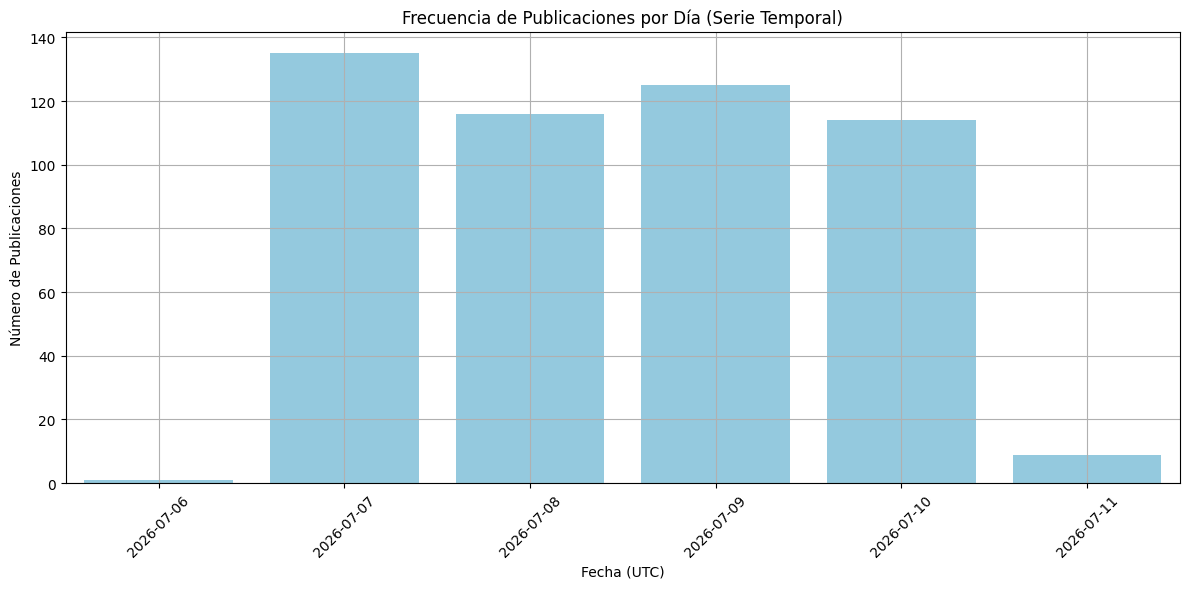

In [66]:
# Asegurarse de que la columna 'created_at_utc' sea de tipo datetime
several_posts_df['created_at_utc'] = pd.to_datetime(all_posts_df['created_at_utc'], format='ISO8601')

# Establecer 'created_at_utc' como el índice del DataFrame para facilitar el remuestreo
# y crear una serie temporal de la frecuencia de publicaciones.
posts_per_day = all_posts_df.set_index('created_at_utc').resample('D').size()

# Crear una lista de etiquetas de fecha sin la hora para el eje X
date_labels = [d.strftime('%Y-%m-%d') for d in posts_per_day.index]

# Crear la visualización de la serie temporal como un gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x=date_labels, y=posts_per_day.values, color='skyblue')
plt.title('Frecuencia de Publicaciones por Día (Serie Temporal)')
plt.xlabel('Fecha (UTC)')
plt.ylabel('Número de Publicaciones')
plt.xticks(rotation=45) # Rotar las etiquetas del eje x para mejor legibilidad
plt.grid(True)
plt.tight_layout() # Ajustar el diseño para evitar el recorte de etiquetas
plt.show()

In [67]:
several_posts_df.to_csv('several_posts_df.csv', index=False)

### Script para recuperar más de 100 publicaciones de la misma cuenta en distintas *queries*

In [49]:
from typing import Optional

def fetch_posts_batch(client: Client, handle: str, limit: int, cursor: Optional[str] = None) -> tuple[list, Optional[str]]:
    """
    Recupera un lote de publicaciones para un handle de Bluesky, comenzando desde un cursor si se proporciona.
    Devuelve la lista de publicaciones y el cursor para el siguiente lote.
    """
    posts_data = []
    next_cursor = None
    try:
        params = {'actor': handle, 'limit': limit}
        if cursor:
            params['cursor'] = cursor

        profile_feed = client.app.bsky.feed.get_author_feed(params=params)

        for feed_view in profile_feed.feed:
            post = feed_view.post
            posts_data.append({
                'created_at_utc': post.record.created_at, # Esta marca de tiempo ya está en UTC
                'author_handle': post.author.handle,
                'post_text': post.record.text
            })
        next_cursor = profile_feed.cursor

    except Exception as e:
        print(f"Error al obtener publicaciones para {handle}: {e}")
    return posts_data, next_cursor


if __name__ == '__main__':
    at_client = Client()
    # Debes reemplazar 'Usuario' y 'Contraseña' con tus credenciales reales de Bluesky
    # Si no tienes una cuenta o no quieres iniciar sesión, podrías estar limitado
    # en lo que puedes obtener o encontrar errores para ciertas consultas.
    try:
        at_client.login('usuario', 'contraseña')
    except Exception as e:
        print(f"Fallo en el inicio de sesión. Algunas funcionalidades pueden estar limitadas: {e}")
        print("Continuando sin iniciar sesión, pero considera usar credenciales válidas.")

    # Inicializar un dataframe vacío para guardar los resultados de varias consultas
    all_posts_df = pd.DataFrame()

    # Diccionario para almacenar el último cursor para cada handle consultado
    handle_cursors = {}
    # Diccionario para almacenar identificadores únicos de posts (para evitar duplicados)
    handle_unique_posts_ids = {}

    while True:
        input_handle = input('\nPor favor, introduce el handle del usuario (ej. revistaraya.bsky.social): ')
        try:
            num_posts_str = input('¿Cuántas publicaciones para esta consulta (max:100)?: ')
            num_posts_this_query = int(num_posts_str)
            if num_posts_this_query <= 0:
                print("El número de publicaciones debe ser un entero positivo.")
                continue
        except ValueError:
            print("Entrada inválida para el número de publicaciones. Por favor, introduce un número entero.")
            continue

        # Obtener el cursor almacenado para este handle, o None si es la primera vez
        current_cursor = handle_cursors.get(input_handle)
        # Obtener o inicializar el set de IDs de posts únicos para este handle
        unique_posts_ids = handle_unique_posts_ids.setdefault(input_handle, set())

        new_posts_fetched_in_this_interaction = []
        posts_remaining_to_fetch = num_posts_this_query

        # Bucle para realizar múltiples llamadas a la API (paginación)
        while posts_remaining_to_fetch > 0:
            batch_limit = min(100, posts_remaining_to_fetch) # Máximo 100 posts por llamada API
            print(f"Recuperando {batch_limit} publicaciones para {input_handle} desde el cursor: {current_cursor}")

            # Llamar a la función que recupera un lote de posts
            batch_results, next_cursor = fetch_posts_batch(at_client, input_handle, batch_limit, current_cursor)

            if not batch_results and current_cursor is None: # No se encontraron publicaciones en absoluto
                print(f"No se encontraron publicaciones para {input_handle}.")
                break
            elif not batch_results and current_cursor is not None: # No hay más publicaciones después del cursor actual
                print(f"No se encontraron más publicaciones para {input_handle} después del cursor: {current_cursor}.")
                break

            # Filtrar publicaciones duplicadas y añadir las nuevas
            for post in batch_results:
                # Usamos la marca de tiempo y el texto como un identificador único (heurístico)
                post_id = (post['created_at_utc'], post['post_text'])
                if post_id not in unique_posts_ids:
                    new_posts_fetched_in_this_interaction.append(post)
                    unique_posts_ids.add(post_id)

            posts_remaining_to_fetch -= len(batch_results) # Restar la cantidad de posts realmente recuperados
            current_cursor = next_cursor # Actualizar el cursor para el siguiente lote

            if not next_cursor: # Si no hay un siguiente cursor, hemos llegado al final del feed
                print(f"Se ha llegado al final del feed para {input_handle}.")
                break
            # Pequeña pausa para evitar sobrecargar la API y posibles bloqueos
            time.sleep(0.5)

        # Almacenar el último cursor para este handle para futuras consultas
        handle_cursors[input_handle] = current_cursor

        if new_posts_fetched_in_this_interaction:
            new_posts_df = pd.DataFrame(new_posts_fetched_in_this_interaction)

            if all_posts_df.empty:
                all_posts_df = new_posts_df
            else:
                all_posts_df = pd.concat([all_posts_df, new_posts_df], ignore_index=True)

            print(f"\nSe recuperaron {len(new_posts_fetched_in_this_interaction)} NUEVAS publicaciones para {input_handle}.")
            print(f"El DataFrame combinado ahora tiene {len(all_posts_df)} publicaciones.\n")
            display(all_posts_df)
        else:
            print(f"No se recuperaron nuevas publicaciones para {input_handle} o se han alcanzado todas las publicaciones disponibles.")

        another_query = input('\n¿Quieres hacer otra consulta? (yes/no): ').lower()
        if another_query != 'yes':
            break


Por favor, introduce el handle del usuario (ej. revistaraya.bsky.social): elespectador.com
¿Cuántas publicaciones para esta consulta (max:100)?: 100
Recuperando 100 publicaciones para elespectador.com desde el cursor: None

Se recuperaron 100 NUEVAS publicaciones para elespectador.com.
El DataFrame combinado ahora tiene 100 publicaciones.



,created_at_utc,author_handle,post_text
0,2026-07-11T01:05:25+00:00,elespectador.com,El exmagistrado fue capturado en 2023 para cum...
1,2026-07-11T01:04:25+00:00,elespectador.com,El Brent pasó de USD 144 a USD 77 tras el cier...
2,2026-07-11T01:03:24+00:00,elespectador.com,El alto tribunal concluyó que la funcionaria n...
3,2026-07-11T01:02:25+00:00,elespectador.com,Rodrigo Lara y Lidio García abren puerta al Co...
4,2026-07-11T00:56:27+00:00,elespectador.com,Las dos compañías habían sellado una alianza e...
...,...,...,...
95,2026-07-10T12:40:21+00:00,elespectador.com,"Argentina, bajo el liderazgo de Lionel Messi, ..."
96,2026-07-10T12:28:20+00:00,elespectador.com,"El jugador noruego Erling Haaland, además de s..."
97,2026-07-10T12:24:21+00:00,elespectador.com,El exfuncionario buscaba acercarse a una event...
98,2026-07-10T12:12:22+00:00,elespectador.com,El duelo entre Noruega e Inglaterra enfrenta a...



¿Quieres hacer otra consulta? (yes/no): yes

Por favor, introduce el handle del usuario (ej. revistaraya.bsky.social): elespectador.com
¿Cuántas publicaciones para esta consulta (max:100)?: 100
Recuperando 100 publicaciones para elespectador.com desde el cursor: 2026-07-10T12:03:25Z

Se recuperaron 100 NUEVAS publicaciones para elespectador.com.
El DataFrame combinado ahora tiene 200 publicaciones.



,created_at_utc,author_handle,post_text
0,2026-07-11T01:05:25+00:00,elespectador.com,El exmagistrado fue capturado en 2023 para cum...
1,2026-07-11T01:04:25+00:00,elespectador.com,El Brent pasó de USD 144 a USD 77 tras el cier...
2,2026-07-11T01:03:24+00:00,elespectador.com,El alto tribunal concluyó que la funcionaria n...
3,2026-07-11T01:02:25+00:00,elespectador.com,Rodrigo Lara y Lidio García abren puerta al Co...
4,2026-07-11T00:56:27+00:00,elespectador.com,Las dos compañías habían sellado una alianza e...
...,...,...,...
195,2026-07-09T15:32:32+00:00,elespectador.com,Los primeros jugadores llegaron el miércoles 8...
196,2026-07-09T15:26:19+00:00,elespectador.com,Familias aseguran que la falta de maquinaria ...
197,2026-07-09T15:04:22+00:00,elespectador.com,La Agencia Distrital de Empleo realizará dos c...
198,2026-07-09T15:03:23+00:00,elespectador.com,"Capítulo de “Esta improbable tierra prometida""..."



¿Quieres hacer otra consulta? (yes/no): yes

Por favor, introduce el handle del usuario (ej. revistaraya.bsky.social): elespectador.com
¿Cuántas publicaciones para esta consulta (max:100)?: 100
Recuperando 100 publicaciones para elespectador.com desde el cursor: 2026-07-09T15:02:24Z

Se recuperaron 100 NUEVAS publicaciones para elespectador.com.
El DataFrame combinado ahora tiene 300 publicaciones.



...


¿Quieres hacer otra consulta? (yes/no): yes

Por favor, introduce el handle del usuario (ej. revistaraya.bsky.social): elespectador.com
¿Cuántas publicaciones para esta consulta (max:100)?: 100
Recuperando 100 publicaciones para elespectador.com desde el cursor: 2026-07-08T17:46:26Z

Se recuperaron 100 NUEVAS publicaciones para elespectador.com.
El DataFrame combinado ahora tiene 400 publicaciones.



,created_at_utc,author_handle,post_text
0,2026-07-11T01:05:25+00:00,elespectador.com,El exmagistrado fue capturado en 2023 para cum...
1,2026-07-11T01:04:25+00:00,elespectador.com,El Brent pasó de USD 144 a USD 77 tras el cier...
2,2026-07-11T01:03:24+00:00,elespectador.com,El alto tribunal concluyó que la funcionaria n...
3,2026-07-11T01:02:25+00:00,elespectador.com,Rodrigo Lara y Lidio García abren puerta al Co...
4,2026-07-11T00:56:27+00:00,elespectador.com,Las dos compañías habían sellado una alianza e...
...,...,...,...
395,2026-07-07T19:30:24+00:00,elespectador.com,Los mantenimientos en la red finalizarán al me...
396,2026-07-07T19:07:22+00:00,elespectador.com,El equipo de Néstor Lorenzo ya definió los onc...
397,2026-07-07T19:06:36+00:00,elespectador.com,Air-e detectó 264 conexiones ilegales de energ...
398,2026-07-07T19:04:40+00:00,elespectador.com,El presidente electo construye el circulo más ...



¿Quieres hacer otra consulta? (yes/no): yes

Por favor, introduce el handle del usuario (ej. revistaraya.bsky.social): elespectador.com
¿Cuántas publicaciones para esta consulta (max:100)?: 100
Recuperando 100 publicaciones para elespectador.com desde el cursor: 2026-07-07T19:03:22Z

Se recuperaron 100 NUEVAS publicaciones para elespectador.com.
El DataFrame combinado ahora tiene 500 publicaciones.



,created_at_utc,author_handle,post_text
0,2026-07-11T01:05:25+00:00,elespectador.com,El exmagistrado fue capturado en 2023 para cum...
1,2026-07-11T01:04:25+00:00,elespectador.com,El Brent pasó de USD 144 a USD 77 tras el cier...
2,2026-07-11T01:03:24+00:00,elespectador.com,El alto tribunal concluyó que la funcionaria n...
3,2026-07-11T01:02:25+00:00,elespectador.com,Rodrigo Lara y Lidio García abren puerta al Co...
4,2026-07-11T00:56:27+00:00,elespectador.com,Las dos compañías habían sellado una alianza e...
...,...,...,...
495,2026-07-07T00:06:25+00:00,elespectador.com,El mandatario colombiano acusó al abogado esta...
496,2026-07-07T00:05:25+00:00,elespectador.com,"""Al señor Presidente, mi gratitud por haberme ..."
497,2026-07-07T00:04:27+00:00,elespectador.com,La interrupción del servicio hace parte de un ...
498,2026-07-07T00:03:27+00:00,elespectador.com,Ya inició la consulta previa del proyecto de M...



¿Quieres hacer otra consulta? (yes/no): no


In [50]:
display(all_posts_df)

,created_at_utc,author_handle,post_text
0,2026-07-11T01:05:25+00:00,elespectador.com,El exmagistrado fue capturado en 2023 para cum...
1,2026-07-11T01:04:25+00:00,elespectador.com,El Brent pasó de USD 144 a USD 77 tras el cier...
2,2026-07-11T01:03:24+00:00,elespectador.com,El alto tribunal concluyó que la funcionaria n...
3,2026-07-11T01:02:25+00:00,elespectador.com,Rodrigo Lara y Lidio García abren puerta al Co...
4,2026-07-11T00:56:27+00:00,elespectador.com,Las dos compañías habían sellado una alianza e...
...,...,...,...
495,2026-07-07T00:06:25+00:00,elespectador.com,El mandatario colombiano acusó al abogado esta...
496,2026-07-07T00:05:25+00:00,elespectador.com,"""Al señor Presidente, mi gratitud por haberme ..."
497,2026-07-07T00:04:27+00:00,elespectador.com,La interrupción del servicio hace parte de un ...
498,2026-07-07T00:03:27+00:00,elespectador.com,Ya inició la consulta previa del proyecto de M...


In [ ]:
several_posts_df.describe()

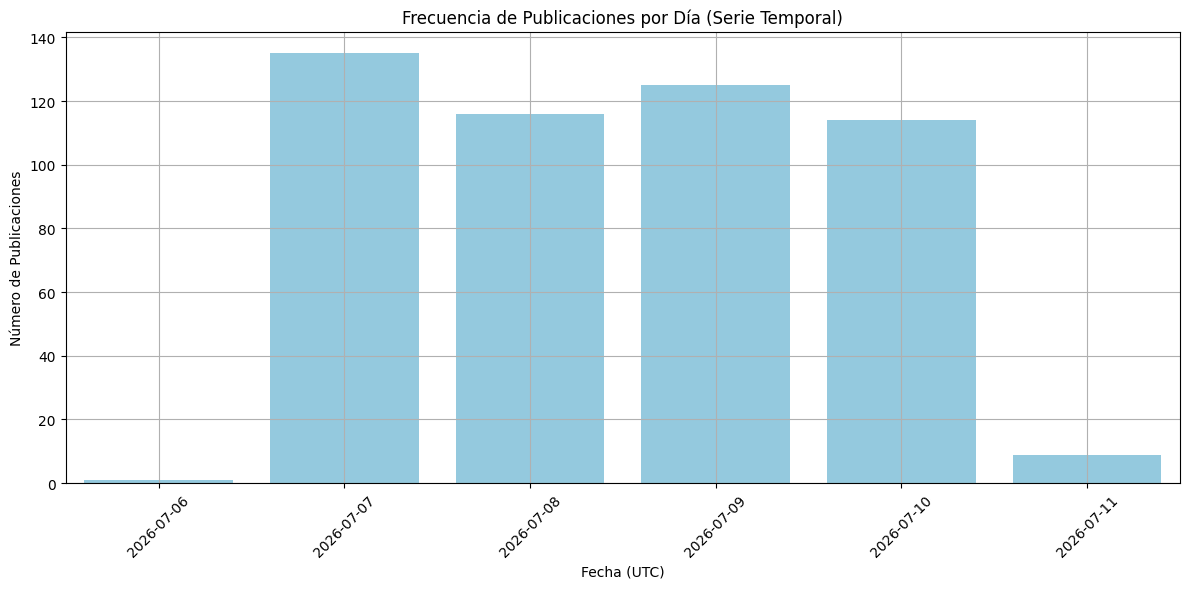

In [51]:
# Asegurarse de que la columna 'created_at_utc' sea de tipo datetime
all_posts_df['created_at_utc'] = pd.to_datetime(all_posts_df['created_at_utc'], format='ISO8601')

# Establecer 'created_at_utc' como el índice del DataFrame para facilitar el remuestreo
# y crear una serie temporal de la frecuencia de publicaciones.
posts_per_day = all_posts_df.set_index('created_at_utc').resample('D').size()

# Crear una lista de etiquetas de fecha sin la hora para el eje X
date_labels = [d.strftime('%Y-%m-%d') for d in posts_per_day.index]

# Crear la visualización de la serie temporal como un gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x=date_labels, y=posts_per_day.values, color='skyblue')
plt.title('Frecuencia de Publicaciones por Día (Serie Temporal)')
plt.xlabel('Fecha (UTC)')
plt.ylabel('Número de Publicaciones')
plt.xticks(rotation=45) # Rotar las etiquetas del eje x para mejor legibilidad
plt.grid(True)
plt.tight_layout() # Ajustar el diseño para evitar el recorte de etiquetas
plt.show()

In [61]:
all_posts_df.to_csv('all_posts_df.csv', index=False)

### Script interactivo para buscar publicaciones por palabras clave (con paginación)

In [53]:
def fetch_posts_by_keyword_batch(client: Client, query: str, limit: int, cursor: Optional[str] = None) -> tuple[list, Optional[str]]:
    """
    Recupera un lote de publicaciones de Bluesky por palabra clave, comenzando desde un cursor si se proporciona.
    Devuelve la lista de publicaciones y el cursor para el siguiente lote.
    """
    posts_data = []
    next_cursor = None
    try:
        # client.app.bsky.feed.search_posts se usa para buscar por palabras clave
        params = {'q': query, 'limit': limit}
        if cursor:
            params['cursor'] = cursor

        search_results = client.app.bsky.feed.search_posts(params=params)

        for post_view in search_results.posts:
            # Asumiendo que 'post_view' es directamente la información que necesitamos
            # y que tiene una estructura similar a la que obtenemos del feed del autor.
            # Es posible que necesitemos ajustar el acceso a 'created_at', 'author.handle', 'text'
            # dependiendo de la estructura exacta de 'search_posts' response.
            posts_data.append({
                'created_at_utc': post_view.indexed_at, # Para búsquedas, a menudo se usa indexed_at
                'author_handle': post_view.author.handle,
                'post_text': post_view.record.text,
                'cid': post_view.cid # Añadir Content ID para asegurar unicidad
            })
        next_cursor = search_results.cursor

    except Exception as e:
        print(f"Error al obtener publicaciones por palabra clave '{query}': {e}")
    return posts_data, next_cursor

In [54]:
if __name__ == '__main__':
    # Re-utilizamos el cliente Bluesky ya inicializado. Si no lo estuviera, se inicializaría aquí.
    try:
        at_client
    except NameError:
        at_client = Client()
        try:
            # Escribe tu usuario y contraseña
            at_client.login('usuario', 'contraseña')
        except Exception as e:
            print(f"Fallo en el inicio de sesión para el cliente de palabras clave. Algunas funcionalidades pueden estar limitadas: {e}")
            print("Continuando sin iniciar sesión, pero considera usar credenciales válidas.")

    # Inicializar un dataframe vacío para guardar los resultados de varias consultas por palabra clave
    results_keyword_df = pd.DataFrame()

    # Diccionario para almacenar el último cursor para cada palabra clave consultada
    keyword_cursors = {}
    # Diccionario para almacenar identificadores únicos de posts (para evitar duplicados)
    keyword_unique_posts_ids = {}

    while True:
        input_keyword = input('\nPor favor, introduce la palabra clave o frase para buscar (ej. "inteligencia artificial"): ')
        if not input_keyword:
            print("La palabra clave no puede estar vacía.")
            continue

        try:
            num_posts_str = input('¿Cuántas publicaciones quieres recuperar en esta consulta? (Máx. 100 por llamada API, pero haremos múltiples llamadas si es necesario): ')
            num_posts_this_query = int(num_posts_str)
            if num_posts_this_query <= 0:
                print("El número de publicaciones debe ser un entero positivo.")
                continue
        except ValueError:
            print("Entrada inválida para el número de publicaciones. Por favor, introduce un número entero.")
            continue

        # Obtener el cursor almacenado para esta palabra clave, o None si es la primera vez
        current_cursor = keyword_cursors.get(input_keyword)
        # Obtener o inicializar el set de IDs de posts únicos para esta palabra clave
        unique_posts_ids = keyword_unique_posts_ids.setdefault(input_keyword, set())

        new_posts_fetched_in_this_interaction = []
        posts_remaining_to_fetch = num_posts_this_query

        # Bucle para realizar múltiples llamadas a la API (paginación)
        while posts_remaining_to_fetch > 0:
            batch_limit = min(100, posts_remaining_to_fetch) # Máximo 100 posts por llamada API
            print(f"Recuperando {batch_limit} publicaciones para la palabra clave '{input_keyword}' desde el cursor: {current_cursor}")

            # Llamar a la función que recupera un lote de posts por palabra clave
            batch_results, next_cursor = fetch_posts_by_keyword_batch(at_client, input_keyword, batch_limit, current_cursor)

            if not batch_results and current_cursor is None: # No se encontraron publicaciones en absoluto
                print(f"No se encontraron publicaciones para la palabra clave '{input_keyword}'.")
                break
            elif not batch_results and current_cursor is not None: # No hay más publicaciones después del cursor actual
                print(f"No se encontraron más publicaciones para la palabra clave '{input_keyword}' después del cursor: {current_cursor}.")
                break

            # Filtrar publicaciones duplicadas y añadir las nuevas usando 'cid' para mayor robustez
            for post in batch_results:
                if post['cid'] not in unique_posts_ids:
                    new_posts_fetched_in_this_interaction.append(post)
                    unique_posts_ids.add(post['cid'])

            posts_remaining_to_fetch -= len(batch_results) # Restar la cantidad de posts realmente recuperados del batch
            current_cursor = next_cursor # Actualizar el cursor para el siguiente lote

            if not next_cursor: # Si no hay un siguiente cursor, hemos llegado al final de los resultados
                print(f"Se ha llegado al final de los resultados para la palabra clave '{input_keyword}'.")
                break
            # Pequeña pausa para evitar sobrecargar la API y posibles bloqueos
            time.sleep(0.5)

        # Almacenar el último cursor y los IDs de posts únicos para esta palabra clave para futuras consultas
        keyword_cursors[input_keyword] = current_cursor
        keyword_unique_posts_ids[input_keyword] = unique_posts_ids

        if new_posts_fetched_in_this_interaction:
            new_keyword_posts_df = pd.DataFrame(new_posts_fetched_in_this_interaction)

            if results_keyword_df.empty:
                results_keyword_df = new_keyword_posts_df
            else:
                results_keyword_df = pd.concat([results_keyword_df, new_keyword_posts_df], ignore_index=True)

            print(f"\nSe recuperaron {len(new_posts_fetched_in_this_interaction)} NUEVAS publicaciones para la palabra clave '{input_keyword}'.")
            print(f"El DataFrame 'results_keyword_df' ahora tiene {len(results_keyword_df)} publicaciones (incluyendo las de otras palabras clave si las hubiera).\n")
            display(results_keyword_df)
        else:
            print(f"No se recuperaron nuevas publicaciones para la palabra clave '{input_keyword}' o se han alcanzado todas las publicaciones disponibles.")

        another_query = input('\n¿Quieres buscar otra palabra clave o recuperar MÁS publicaciones para la misma palabra clave? (yes/no): ').lower()
        if another_query != 'yes':
            break


Por favor, introduce la palabra clave o frase para buscar (ej. "inteligencia artificial"): colombia
¿Cuántas publicaciones quieres recuperar en esta consulta? (Máx. 100 por llamada API, pero haremos múltiples llamadas si es necesario): 100
Recuperando 100 publicaciones para la palabra clave 'colombia' desde el cursor: None

Se recuperaron 100 NUEVAS publicaciones para la palabra clave 'colombia'.
El DataFrame 'results_keyword_df' ahora tiene 100 publicaciones (incluyendo las de otras palabras clave si las hubiera).



,created_at_utc,author_handle,post_text,cid
0,2026-07-11T01:46:28.166Z,caribbean.sismos.live,#Caribbean #quake M2.5 | Panama-Colombia Borde...,bafyreifka67pi5dfvvfpsu2to4ianpl7277sltyezbkla...
1,2026-07-11T01:46:25.672Z,colombia.sismos.live,#Colombia #sismo M2.5 | Panama-Colombia Border...,bafyreigkgkmmnptxoy3rr2f3wksvbuga65exsldy7rtxj...
2,2026-07-11T01:44:37.964Z,rafaelaorgana.bsky.social,youtu.be/uiTOi01YeSo?...,bafyreieqzbwkyivtf6zqycmfosfrguqhcgwougvimxatj...
3,2026-07-11T01:38:51.063Z,nestmor.bsky.social,"Si Colombia hubiera ganado, mañana tendríamos ...",bafyreidy5deeys6gijovpdozzrha35e4l6n27rfjfeiea...
4,2026-07-11T01:34:55.472Z,killbaitargentina.bsky.social,Milei busca fortalecer alianzas regionales con...,bafyreia3bklognqtk7lbmgjy3gpnfwe2clq36z6mw6jfr...
...,...,...,...,...
95,2026-07-10T21:11:08.469Z,fintwitter.bsky.social,Shield of Americas: deep concern over recent r...,bafyreihp454fltzpappdmy2woif63jnchqsrso4w4gsvw...
96,2026-07-10T21:11:05.878Z,coveringclimatenow.org,Climate activists in Colombia react to the ele...,bafyreicv26wqgixi6q7zfqjdura62oe652p3f4e64neno...
97,2026-07-10T21:10:55.665Z,grainydispatch.bsky.social,🚨 #BREAKING : SHIELD OF AMERICAS STATEMENT: DE...,bafyreib53cgagzswgmzrgklszstgovrbxjr6owc5bc3pd...
98,2026-07-10T21:09:52.478Z,animatorswanted.bsky.social,\nStudio: iKartoons Animation\n\nLooking for M...,bafyreigdwf7u57pekunk3pmppajltgqukzhefg2s6wojc...



¿Quieres buscar otra palabra clave o recuperar MÁS publicaciones para la misma palabra clave? (yes/no): yes

Por favor, introduce la palabra clave o frase para buscar (ej. "inteligencia artificial"): colombia
¿Cuántas publicaciones quieres recuperar en esta consulta? (Máx. 100 por llamada API, pero haremos múltiples llamadas si es necesario): 100
Recuperando 100 publicaciones para la palabra clave 'colombia' desde el cursor: eyJzIjpbMTc4MzcxNzMxMjAwMCwiZGlkOnBsYzpwYXdtcmZ2YWd6ZG5wNW91cGZqbXB5NHQiLCIzbXFkM2Vqc2Vma24yIl19

Se recuperaron 100 NUEVAS publicaciones para la palabra clave 'colombia'.
El DataFrame 'results_keyword_df' ahora tiene 200 publicaciones (incluyendo las de otras palabras clave si las hubiera).



,created_at_utc,author_handle,post_text,cid
0,2026-07-11T01:46:28.166Z,caribbean.sismos.live,#Caribbean #quake M2.5 | Panama-Colombia Borde...,bafyreifka67pi5dfvvfpsu2to4ianpl7277sltyezbkla...
1,2026-07-11T01:46:25.672Z,colombia.sismos.live,#Colombia #sismo M2.5 | Panama-Colombia Border...,bafyreigkgkmmnptxoy3rr2f3wksvbuga65exsldy7rtxj...
2,2026-07-11T01:44:37.964Z,rafaelaorgana.bsky.social,youtu.be/uiTOi01YeSo?...,bafyreieqzbwkyivtf6zqycmfosfrguqhcgwougvimxatj...
3,2026-07-11T01:38:51.063Z,nestmor.bsky.social,"Si Colombia hubiera ganado, mañana tendríamos ...",bafyreidy5deeys6gijovpdozzrha35e4l6n27rfjfeiea...
4,2026-07-11T01:34:55.472Z,killbaitargentina.bsky.social,Milei busca fortalecer alianzas regionales con...,bafyreia3bklognqtk7lbmgjy3gpnfwe2clq36z6mw6jfr...
...,...,...,...,...
195,2026-07-10T16:39:04.964Z,altaveu.com,L’extrem colombià posa funt final a la seva et...,bafyreidpqfvbmtalqipfn7tfghp4o5wgbotchddfi7m5t...
196,2026-07-10T16:39:09.469Z,ciudadvalencia.bsky.social,,bafyreign3ryb2e4a2ysmkfnaxpy2lsnhqnd4ywslxrjw5...
197,2026-07-10T16:38:26.764Z,plantaobrasil.bsky.social,Após vitória do extremista Abelardo de la Espr...,bafyreieigwpkiy4lnpxw3zcdoatvv77garvyvw73fniws...
198,2026-07-10T16:37:05.168Z,voych.bsky.social,"Producers of horror thriller ""The Whistler"" re...",bafyreiaubeoyvyh3cudgjhgxlyyltyk6w7rfzjvvsgtct...



¿Quieres buscar otra palabra clave o recuperar MÁS publicaciones para la misma palabra clave? (yes/no): yes

Por favor, introduce la palabra clave o frase para buscar (ej. "inteligencia artificial"): colombia
¿Cuántas publicaciones quieres recuperar en esta consulta? (Máx. 100 por llamada API, pero haremos múltiples llamadas si es necesario): 100
Recuperando 100 publicaciones para la palabra clave 'colombia' desde el cursor: eyJzIjpbMTc4MzcwMTMwMTAwMCwiZGlkOnBsYzoyNXZhaHZmcTRmazV5NGY2YjduZjZydXYiLCIzbXFjbGRicnBnYjJnIl19
Recuperando 3 publicaciones para la palabra clave 'colombia' desde el cursor: eyJzIjpbMTc4MzY4NTczODAwMCwiZGlkOnBsYzpwaGxhampqc29tM3ZhNzRoY25wc3V0cHciLCIzbXFjNHRoMmwzYzJ6Il19

Se recuperaron 99 NUEVAS publicaciones para la palabra clave 'colombia'.
El DataFrame 'results_keyword_df' ahora tiene 299 publicaciones (incluyendo las de otras palabras clave si las hubiera).



...


¿Quieres buscar otra palabra clave o recuperar MÁS publicaciones para la misma palabra clave? (yes/no): yes

Por favor, introduce la palabra clave o frase para buscar (ej. "inteligencia artificial"): colombia
¿Cuántas publicaciones quieres recuperar en esta consulta? (Máx. 100 por llamada API, pero haremos múltiples llamadas si es necesario): 100
Recuperando 100 publicaciones para la palabra clave 'colombia' desde el cursor: eyJzIjpbMTc4MzY1NjQzMTAwMCwiZGlkOnBsYzptZWFleGYydGc0bXRleGZkYzNtZnJld2YiLCIzbXFiYmsycmptNDJzIl19
Recuperando 3 publicaciones para la palabra clave 'colombia' desde el cursor: eyJzIjpbMTc4MzYzNzU1NTAwMCwiZGlkOnBsYzp6aHZzdGJtaG14ZzZ3YXV2a21pNGU3Z3YiLCIzbXFhcHhpdG1tazJ5Il19

Se recuperaron 100 NUEVAS publicaciones para la palabra clave 'colombia'.
El DataFrame 'results_keyword_df' ahora tiene 499 publicaciones (incluyendo las de otras palabras clave si las hubiera).



,created_at_utc,author_handle,post_text,cid
0,2026-07-11T01:46:28.166Z,caribbean.sismos.live,#Caribbean #quake M2.5 | Panama-Colombia Borde...,bafyreifka67pi5dfvvfpsu2to4ianpl7277sltyezbkla...
1,2026-07-11T01:46:25.672Z,colombia.sismos.live,#Colombia #sismo M2.5 | Panama-Colombia Border...,bafyreigkgkmmnptxoy3rr2f3wksvbuga65exsldy7rtxj...
2,2026-07-11T01:44:37.964Z,rafaelaorgana.bsky.social,youtu.be/uiTOi01YeSo?...,bafyreieqzbwkyivtf6zqycmfosfrguqhcgwougvimxatj...
3,2026-07-11T01:38:51.063Z,nestmor.bsky.social,"Si Colombia hubiera ganado, mañana tendríamos ...",bafyreidy5deeys6gijovpdozzrha35e4l6n27rfjfeiea...
4,2026-07-11T01:34:55.472Z,killbaitargentina.bsky.social,Milei busca fortalecer alianzas regionales con...,bafyreia3bklognqtk7lbmgjy3gpnfwe2clq36z6mw6jfr...
...,...,...,...,...
494,2026-07-09T22:59:15.865Z,gazetadopovo.com.br,,bafyreiabrmu3fycwinewb6wei4qmmjp5cosin5sziu7en...
495,2026-07-09T22:52:46.773Z,extremetemps.bsky.social,HISTORIC HEAT IN THE CARIBBEAN\nEvery single c...,bafyreibaqizmor34irithy27fdtgycbnof2rp5t6iwnmz...
496,2026-07-09T22:51:58.569Z,copdeb.metalhead.club.ap.brid.gy,Did #Colombia made a mistake when promoting #s...,bafyreiewpxe2axm6uo7db4d4o6sdyrlxvtpl7iekyd76o...
497,2026-07-09T22:51:44.865Z,fervaferva.bsky.social,favoritas só se for as nossas né kkkkkkkk mas ...,bafyreif43soqhcsnb7gxyddus6dobjiui6iwkm7xqtwfl...



¿Quieres buscar otra palabra clave o recuperar MÁS publicaciones para la misma palabra clave? (yes/no): yes

Por favor, introduce la palabra clave o frase para buscar (ej. "inteligencia artificial"): colombia
¿Cuántas publicaciones quieres recuperar en esta consulta? (Máx. 100 por llamada API, pero haremos múltiples llamadas si es necesario): 100
Recuperando 100 publicaciones para la palabra clave 'colombia' desde el cursor: eyJzIjpbMTc4MzYzNzI1NjAwMCwiZGlkOnBsYzpwYXdtcmZ2YWd6ZG5wNW91cGZqbXB5NHQiLCIzbXFhcjNsbGIyNWkyIl19
Recuperando 1 publicaciones para la palabra clave 'colombia' desde el cursor: eyJzIjpbMTc4MzYyNjMyMDAwMCwiZGlkOnBsYzp2cnoycnl4YXdzb3J6Z3M0emI0dG5kYXIiLCIzbXFhZmlvcXZmeDJwIl19

Se recuperaron 100 NUEVAS publicaciones para la palabra clave 'colombia'.
El DataFrame 'results_keyword_df' ahora tiene 599 publicaciones (incluyendo las de otras palabras clave si las hubiera).



,created_at_utc,author_handle,post_text,cid
0,2026-07-11T01:46:28.166Z,caribbean.sismos.live,#Caribbean #quake M2.5 | Panama-Colombia Borde...,bafyreifka67pi5dfvvfpsu2to4ianpl7277sltyezbkla...
1,2026-07-11T01:46:25.672Z,colombia.sismos.live,#Colombia #sismo M2.5 | Panama-Colombia Border...,bafyreigkgkmmnptxoy3rr2f3wksvbuga65exsldy7rtxj...
2,2026-07-11T01:44:37.964Z,rafaelaorgana.bsky.social,youtu.be/uiTOi01YeSo?...,bafyreieqzbwkyivtf6zqycmfosfrguqhcgwougvimxatj...
3,2026-07-11T01:38:51.063Z,nestmor.bsky.social,"Si Colombia hubiera ganado, mañana tendríamos ...",bafyreidy5deeys6gijovpdozzrha35e4l6n27rfjfeiea...
4,2026-07-11T01:34:55.472Z,killbaitargentina.bsky.social,Milei busca fortalecer alianzas regionales con...,bafyreia3bklognqtk7lbmgjy3gpnfwe2clq36z6mw6jfr...
...,...,...,...,...
594,2026-07-09T19:54:08.436Z,nom-de-plum.bsky.social,They are good at predicting the World Cup . . .,bafyreigfzdmfu2rdq52bt4yg43mm37zuwukpcc24fcie4...
595,2026-07-09T19:53:39.318Z,lil-jamie.bsky.social,"..the outcome, of course, is England winning t...",bafyreieeg4j3ac6gotdgrydo3s4433uedlw2whjgddth6...
596,2026-07-09T19:46:12.925Z,janekeithduran.bsky.social,Esto es solapadamente una amenaza sólo porque ...,bafyreic6auls5hogzknownubigkfd3e7tyyo5v2dkzdc4...
597,2026-07-09T19:45:22.931Z,elcomercio.pe,Un juzgado en Colombia ordenó el embargo de un...,bafyreiaq6budxrjpcr5tspkoktg5e7v6regckvwjix4ow...



¿Quieres buscar otra palabra clave o recuperar MÁS publicaciones para la misma palabra clave? (yes/no): no


In [55]:
display(results_keyword_df)

,created_at_utc,author_handle,post_text,cid
0,2026-07-11T01:46:28.166Z,caribbean.sismos.live,#Caribbean #quake M2.5 | Panama-Colombia Borde...,bafyreifka67pi5dfvvfpsu2to4ianpl7277sltyezbkla...
1,2026-07-11T01:46:25.672Z,colombia.sismos.live,#Colombia #sismo M2.5 | Panama-Colombia Border...,bafyreigkgkmmnptxoy3rr2f3wksvbuga65exsldy7rtxj...
2,2026-07-11T01:44:37.964Z,rafaelaorgana.bsky.social,youtu.be/uiTOi01YeSo?...,bafyreieqzbwkyivtf6zqycmfosfrguqhcgwougvimxatj...
3,2026-07-11T01:38:51.063Z,nestmor.bsky.social,"Si Colombia hubiera ganado, mañana tendríamos ...",bafyreidy5deeys6gijovpdozzrha35e4l6n27rfjfeiea...
4,2026-07-11T01:34:55.472Z,killbaitargentina.bsky.social,Milei busca fortalecer alianzas regionales con...,bafyreia3bklognqtk7lbmgjy3gpnfwe2clq36z6mw6jfr...
...,...,...,...,...
594,2026-07-09T19:54:08.436Z,nom-de-plum.bsky.social,They are good at predicting the World Cup . . .,bafyreigfzdmfu2rdq52bt4yg43mm37zuwukpcc24fcie4...
595,2026-07-09T19:53:39.318Z,lil-jamie.bsky.social,"..the outcome, of course, is England winning t...",bafyreieeg4j3ac6gotdgrydo3s4433uedlw2whjgddth6...
596,2026-07-09T19:46:12.925Z,janekeithduran.bsky.social,Esto es solapadamente una amenaza sólo porque ...,bafyreic6auls5hogzknownubigkfd3e7tyyo5v2dkzdc4...
597,2026-07-09T19:45:22.931Z,elcomercio.pe,Un juzgado en Colombia ordenó el embargo de un...,bafyreiaq6budxrjpcr5tspkoktg5e7v6regckvwjix4ow...


In [59]:
all_posts_df.describe()

,created_at_utc,author_handle,post_text
count,500,500,500
unique,NaN,1,500
top,NaN,elespectador.com,Presidente Gustavo Petro convocó a reunión de ...
freq,NaN,500,1
mean,2026-07-09 02:31:34.107999744+00:00,NaN,NaN
min,2026-07-06 23:52:26+00:00,NaN,NaN
25%,2026-07-07 23:03:08.249999872+00:00,NaN,NaN
50%,2026-07-08 23:43:27.500000+00:00,NaN,NaN
75%,2026-07-09 23:53:26.750000128+00:00,NaN,NaN
max,2026-07-11 01:05:25+00:00,NaN,NaN


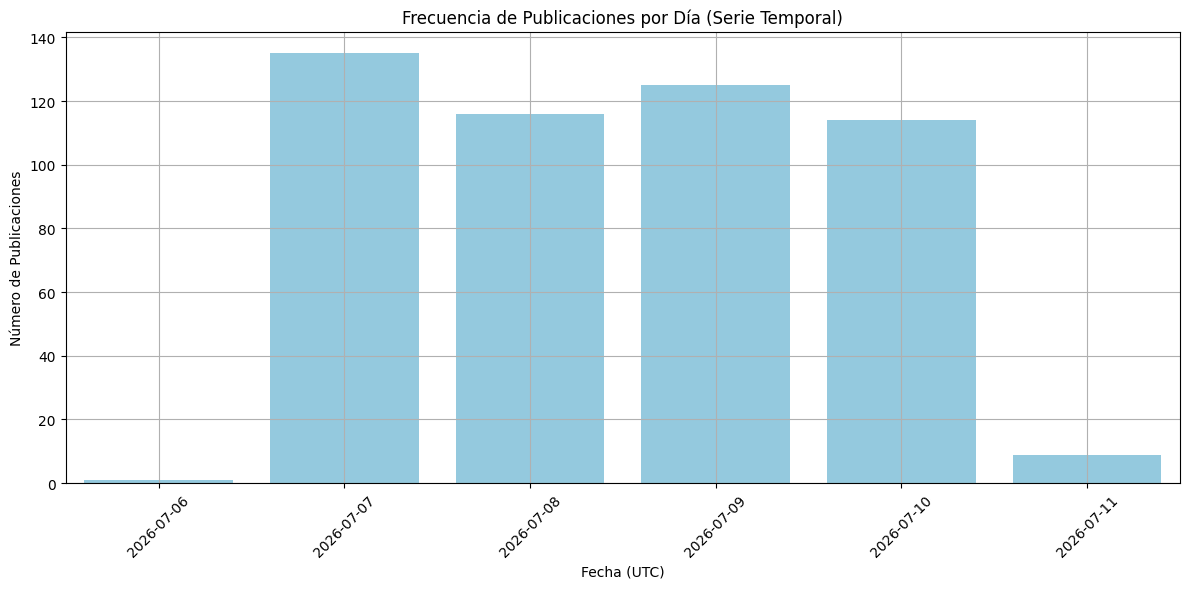

In [56]:
results_keyword_df['created_at_utc'] = pd.to_datetime(all_posts_df['created_at_utc'], format='ISO8601')

# Establecer 'created_at_utc' como el índice del DataFrame para facilitar el remuestreo
# y crear una serie temporal de la frecuencia de publicaciones.
posts_per_day = all_posts_df.set_index('created_at_utc').resample('D').size()

# Crear una lista de etiquetas de fecha sin la hora para el eje X
date_labels = [d.strftime('%Y-%m-%d') for d in posts_per_day.index]

# Crear la visualización de la serie temporal como un gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x=date_labels, y=posts_per_day.values, color='skyblue')
plt.title('Frecuencia de Publicaciones por Día (Serie Temporal)')
plt.xlabel('Fecha (UTC)')
plt.ylabel('Número de Publicaciones')
plt.xticks(rotation=45) # Rotar las etiquetas del eje x para mejor legibilidad
plt.grid(True)
plt.tight_layout() # Ajustar el diseño para evitar el recorte de etiquetas
plt.show()

In [58]:
results_keyword_df.describe()

,created_at_utc,author_handle,post_text,cid
count,500,599,599,599
unique,NaN,406,524,599
top,NaN,las2orillas.co.web.brid.gy,,bafyreig4heqsxnwe2mlnbhr67nqokspg54l4hparkvrmo...
freq,NaN,28,64,1
mean,2026-07-09 02:31:34.108000+00:00,NaN,NaN,NaN
min,2026-07-06 23:52:26+00:00,NaN,NaN,NaN
25%,2026-07-07 23:03:08.249999872+00:00,NaN,NaN,NaN
50%,2026-07-08 23:43:27.500000+00:00,NaN,NaN,NaN
75%,2026-07-09 23:53:26.750000128+00:00,NaN,NaN,NaN
max,2026-07-11 01:05:25+00:00,NaN,NaN,NaN


In [60]:
results_keyword_df.to_csv('results_keywords_df.csv', index=False)